<a href="https://colab.research.google.com/github/committed-kermit/ClassicML/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv('placement.csv')

In [33]:
df.shape

(200, 2)

In [34]:
df.sample(15)

,cgpa,package
119,7.39,2.65
190,6.19,2.69
137,7.14,3.13
92,7.90,4.00
38,8.62,4.36
188,7.35,3.08
165,8.21,4.08
195,6.93,2.46
108,7.76,3.54
60,5.61,2.19


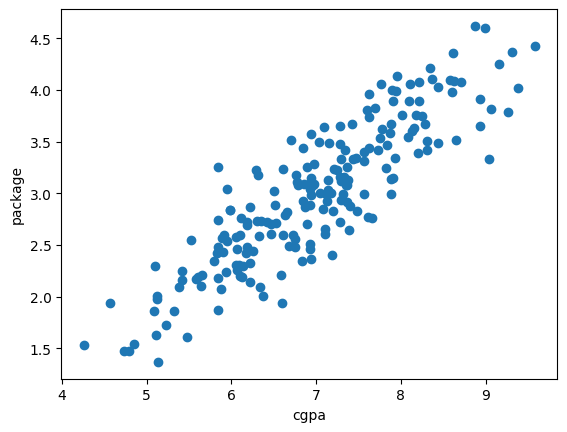

In [35]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [36]:
X,y=df.iloc[:,0:1],df.iloc[:,-1]

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

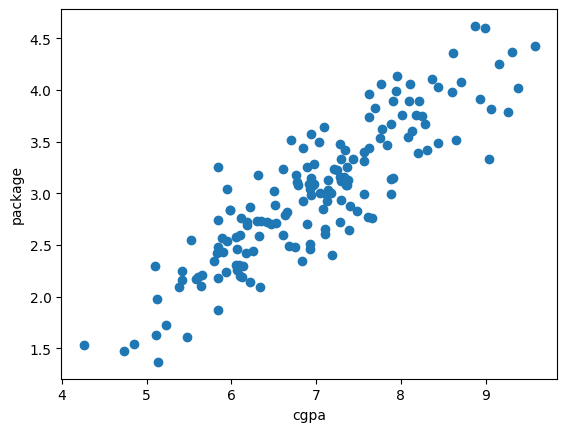

In [38]:
plt.scatter(X_train,y_train)
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [39]:
LR=LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [40]:
LR.coef_

array([0.55795197])

In [41]:
LR.intercept_

np.float64(-0.8961119222429144)

In [42]:
LR.n_features_in_

1

In [43]:
LR.feature_names_in_

array(['cgpa'], dtype=object)

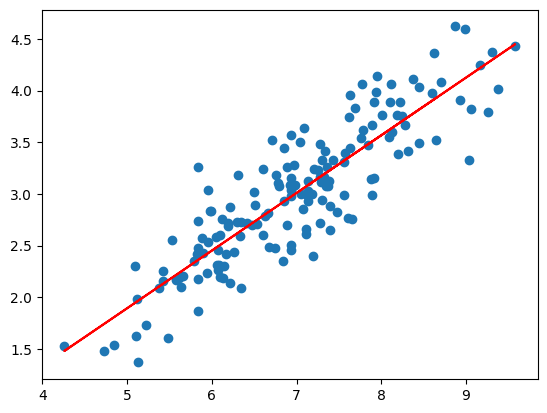

In [44]:
plt.scatter(X_train,y_train)
plt.plot(X_train,LR.predict(X_train),color='red')

In [45]:
print(LR.predict(X_test))
print(np.array(y_test))

[3.89111601 3.09324469 2.38464568 2.57434935 1.6537286  1.77647803
 2.07219258 2.93143862 3.76278706 2.93701814 4.09197872 3.51170867
 2.97049525 2.40138424 3.18809652 3.46707251 1.94386362 3.24389172
 2.97607477 3.41685683 2.55761079 3.16577844 2.85890486 3.12114229
 3.68467378 2.8700639  3.49497011 3.34432308 3.91901361 1.96060218
 3.65119666 3.2104146  3.74046898 2.7863711  2.78079158 3.27178932
 3.52844723 2.61340599 2.65804215 2.71383735]
[4.1  3.49 2.08 2.33 1.94 1.48 1.86 3.09 4.21 2.87 3.65 4.   2.89 2.6
 2.99 3.25 1.86 3.67 2.37 3.42 2.48 3.65 2.6  2.83 4.08 2.56 3.58 3.81
 4.09 2.01 3.63 2.92 3.51 1.94 2.21 3.34 3.34 3.23 2.01 2.61]


In [51]:
print("MSE:",mean_squared_error(y_test,LR.predict(X_test)))

MSE: 0.12129235313495527


In [57]:
print("MAE:",mean_absolute_error(y_test,LR.predict(X_test)))
print("R2:",r2_score(y_test,LR.predict(X_test)))
r2=r2_score(y_test,LR.predict(X_test))

MAE: 0.2884710931878175
R2: 0.780730147510384


In [58]:
X_test.shape

(40, 1)

In [62]:
print("Adjusted R2 Score:",1-((1-r2)*(40-1)/(40-1-1)))

Adjusted R2 Score: 0.7749598882343415


In [63]:
'''
we will now look how an extra unrelated column increase r2 and but decreases adjusted r2 score hence
adjusted r2 score is better than r2 score
'''

'\nwe will now look how an extra unrelated column increase r2 and but decreases adjusted r2 score hence\nadjusted r2 score is better than r2 score\n'

In [65]:
df1=df.copy()
df1['random_feature']=np.random.random(200)

In [66]:
df1.head()

,cgpa,package,random_feature
0,6.89,3.26,0.633047
1,5.12,1.98,0.253992
2,7.82,3.25,0.699554
3,7.42,3.67,0.929462
4,6.94,3.57,0.651111


In [67]:
df1=df1[['cgpa','random_feature','package']]

In [68]:
df1.head()

,cgpa,random_feature,package
0,6.89,0.633047,3.26
1,5.12,0.253992,1.98
2,7.82,0.699554,3.25
3,7.42,0.929462,3.67
4,6.94,0.651111,3.57


In [69]:
df1.corr()

,cgpa,random_feature,package
cgpa,1.000000,-0.008053,0.880692
random_feature,-0.008053,1.000000,-0.002508
package,0.880692,-0.002508,1.000000


In [72]:
X1,y1=df1.iloc[:,0:2],df1.iloc[:,-1]

In [73]:
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=2)

In [74]:
LR1=LinearRegression()
LR1.fit(X1_train,y1_train)

LinearRegression()

In [82]:
print("MSE:",mean_squared_error(y1_test,LR1.predict(X1_test)))
print("MAE:",mean_absolute_error(y1_test,LR1.predict(X1_test)))
print("R2:",r2_score(y1_test,LR1.predict(X1_test)))
r21=r2_score(y1_test,LR1.predict(X1_test))

MSE: 0.1221483242445279
MAE: 0.2910452438044734
R2: 0.7791827403236957


In [83]:
X1_test.shape

(40, 2)

In [84]:
print("Adjusted R2 Score:",1-((1-r21)*(40-1)/(40-1-1)))

Adjusted R2 Score: 0.7733717598058982


In [85]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [86]:
new_df2.sample(5)

,cgpa,iq,package
186,7.84,2.37,3.47
29,7.15,3.09,3.49
47,5.84,2.36,3.26
190,6.19,2.29,2.69
149,8.28,3.47,3.67


Text(0, 0.5, 'Package(in lpa)')

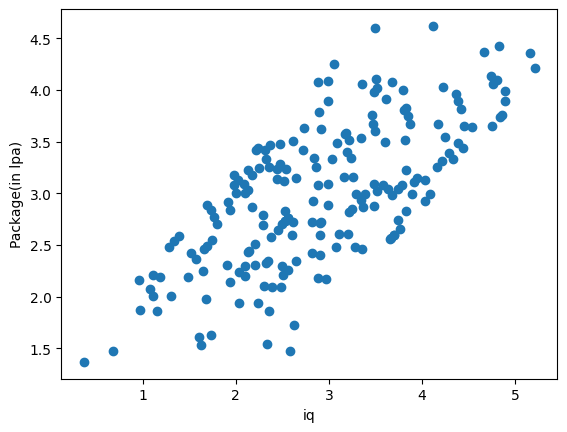

In [87]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [88]:
np.random.randint(-100,100)

10

In [91]:
X2 = new_df2.iloc[:,0:2]
y2 = new_df2.iloc[:,-1]

In [92]:
X2_train,X2_test,y2_train,y2_test = train_test_split(X2,y2,test_size=0.2,random_state=2)

In [94]:
lr2 = LinearRegression()
lr2.fit(X2_train,y2_train)
y2_pred = lr2.predict(X2_test)

In [97]:
print("R2 score",r2_score(y2_test,y2_pred))
r22 = r2_score(y2_test,y2_pred)

R2 score 0.8190716326060385


In [100]:
print("Adjusted R2:",1 - ((1-r22)*(40-1)/(40-1-2)))

Adjusted R2: 0.8092917208550137


In [101]:
!git config --global user.name "committed-kermit"
!git config --global user.email "sablokdaksh06@gmail.com"

In [102]:
!git clone https://github.com/committed-kermit/ClassicML.git

Cloning into 'ClassicML'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [103]:
%cd ClassicML

/content/ClassicML


In [104]:
!git checkout -b linear-regression

Switched to a new branch 'linear-regression'


In [108]:
!cp /content/linear_regression.ipynb .

cp: cannot stat '/content/linear_regression.ipynb': No such file or directory


In [109]:
!ls

README.md  requirements.txt
